<a href="https://colab.research.google.com/github/rchougule12995/Air-Quality-Index-India/blob/master/projects/2025q1/projectA/AB_Testing_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assessment Task: A/B Testing Business Challenge (Evaluating the Impact of Backend Algorithm Tweaks)
<br>The task involves analysing an A/B test for a proposed algorithm tweak for Marketing Campaigns at Marketing Company ABC. The goal is to use causal inference methods to estimate the impact of this modification on three key performance metrics for the Marketing Campaigns: __net revenue, cost and conversions__.  

The test is conducted on a small set of campaigns, with the aim of determining whether the tweak should be implemented across all campaigns managed by company ABC.

In [ ]:
# %%capture
# %pip install pandas
# %pip install matplotlib
# %pip install seaborn
# %pip install plotly
# %pip install stats
# %pip install numpy
# %pip install warnings
# %pip install -U kaleido
# %pip install dataframe_image
# !apt-get install -y pandoc
# !apt-get install -y texlive-xetex texlive-fonts-recommended texlive-plain-generic
# ###Installing the specific libraries that are required for the execution of this jupyter notebook

__Ensure that the jupyter notebook is present in the same folder as the data file. Rename the data file to data_challenge_abtest.csv__

## Data Loading and Exploratory Data Analysis

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import plotly.express as px
from IPython.display import Image
import dataframe_image as dfi
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df=pd.read_csv("data_challenge_abtest.csv")

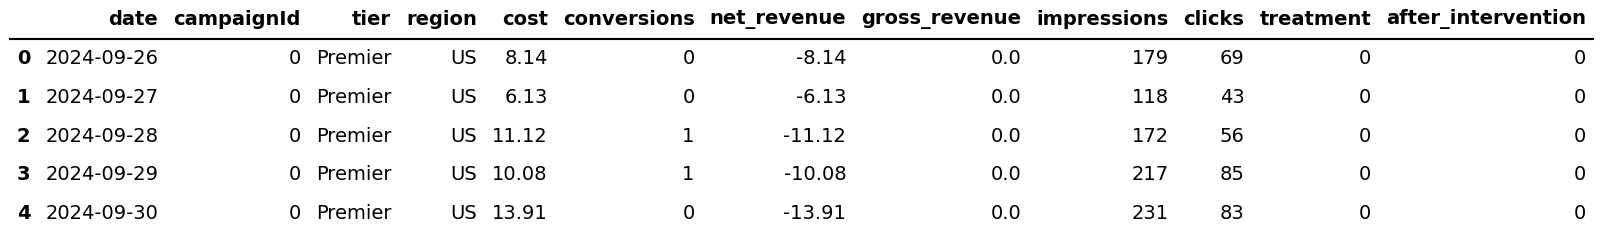

In [ ]:
# df.head()
dfi.export(df.head(), 'df_head.png',table_conversion='matplotlib')
Image("df_head.png")

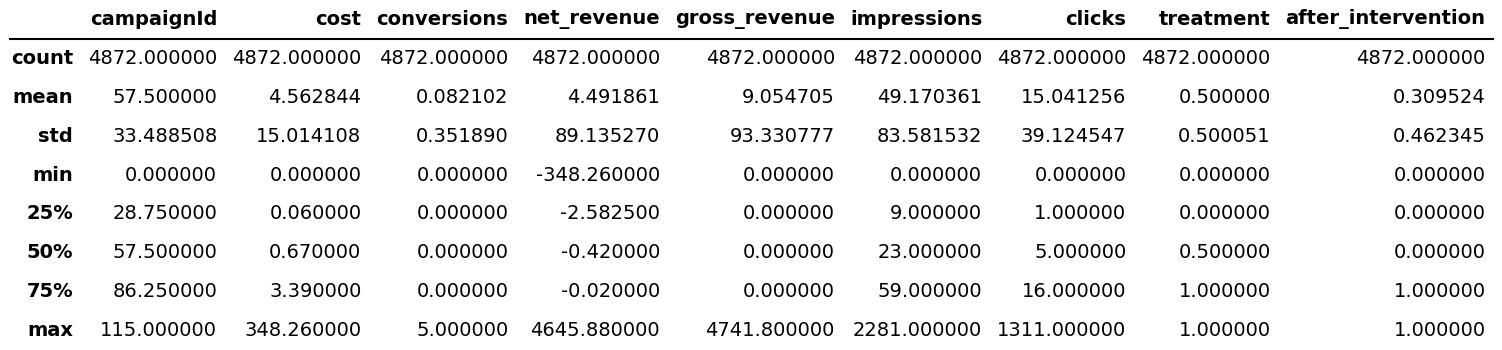

In [ ]:
# df.describe()
dfi.export(df.describe(), 'describe.png',table_conversion='matplotlib')
Image("describe.png")

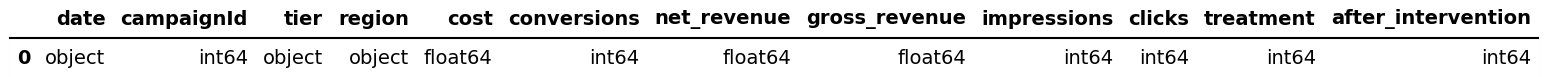

In [ ]:
# df.dtypes
dfi.export(pd.DataFrame(df.dtypes).T, 'data_types.png',table_conversion='matplotlib')
Image("data_types.png")

Updating the datatype of the date field to a pandas datetime for further usage in the analysis.  
Given the fact the dataset is already clean, no further cleaning of the datafields is required as such, and we can proceed with looking and data summary.

In [ ]:
df["date"]=pd.to_datetime(df['date'])

### Summary Statistics around the data distribution

Based on the description of the dataset for the variables:

* `treatment`: If Treatment=1, the data has been further categorised as __Treatment Group__ in visual and text representation.  
If Treatment=0, the data has been further categorised as __Control Group__ in visual and text representation.
* `after_intervention`: If after_intervention=1, the data has been further categorised as __Post-Intervention__ in visual and text representation.  
If after_intervention=0, the data has been further categorised as __Pre-Intervention__ in visual and text representation.

In [ ]:
print("Getting understanding of the frequency distribution for categorical columns:")
for col in df.select_dtypes(include=['object', 'category', 'bool']):
    print(pd.DataFrame(df[col].value_counts().T))
    # print(f"\nColumn: {col}")
    # print(df[col].value_counts())

Getting understanding of the frequency distribution for categorical columns:
              count
tier               
Essential      2730
Professional   1386
Preferred       420
Premier         336
        count
region       
US       4872


The above variables: Tier and Region could be of importance further in the analysis. The variable region, would not contribute much to the analysis, considering the fact that it has only one data point throughout the dataset.  
__However, the variable tier would add an effect to the outcome that we trying to estimate considering the fact that there are different values associated with each campaign.__  
Based on the distribution of the data, it seems a lot of campaigns, more than 50% of the data fall in the Essential tier, whereas Premier campaigns are the lowest in number.

In [ ]:
df[['campaignId','treatment','after_intervention']] = df[['campaignId','treatment','after_intervention']].astype('category')

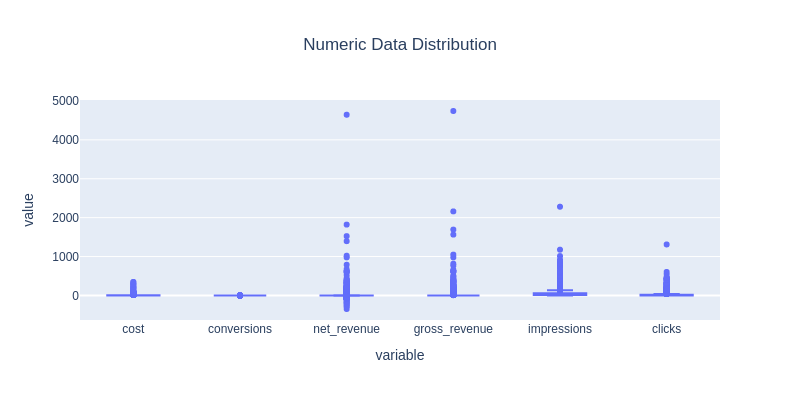

In [ ]:
fig = px.box(df.select_dtypes(include=['number']), y=df.select_dtypes(include=['number']).columns, title="Numeric Data Distribution", width=800,height=400)
fig.update_layout(title_x=0.5)
# fig.show()
fig.write_image("box_plot_data_distribution.png")
Image("box_plot_data_distribution.png")

The above distribution shows there do not seem to be any outliers in any of the metrics that we have in the dataset.

__Summary of each of the metrics that we need to focus on: Cost, Conversions and Revenue__

In [ ]:
total_summary=df.groupby(["treatment","after_intervention"])["cost"].sum().reset_index(name="Total Cost").merge(
    df.groupby(["treatment","after_intervention"])["conversions"].sum().reset_index(name="Total Conversions"),
    on=["treatment","after_intervention"], how="inner"
).merge(
    df.groupby(["treatment","after_intervention"])["net_revenue"].sum().reset_index(name="Net Revenue"),
    on=["treatment","after_intervention"], how="inner"
)

total_summary["treatment"].replace({0:"Control", 1:"Treatment"}, inplace=True)
total_summary["after_intervention"].replace({0:"Pre-Intervention", 1:"Post-Intervention"}, inplace=True)

Below table shows the total cost, total number of conversions and the net revenue for each of the (Control and Treatment) group, before and after the intervention:

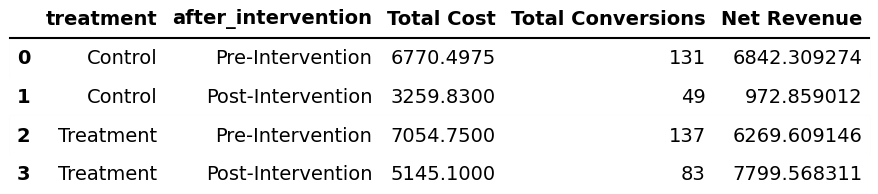

In [ ]:
# total_summary
dfi.export(total_summary, 'total_summary.png',table_conversion='matplotlib')
Image("total_summary.png")

In [ ]:
average_summary=df.groupby(["treatment","after_intervention"])["cost"].mean().reset_index(name="Average Cost").merge(
    df.groupby(["treatment","after_intervention"])["conversions"].mean().reset_index(name="Average Conversions"),
    on=["treatment","after_intervention"], how="inner"
).merge(
    df.groupby(["treatment","after_intervention"])["net_revenue"].mean().reset_index(name="Average Net Revenue"),
    on=["treatment","after_intervention"], how="inner"
)

average_summary["treatment"].replace({0:"Control", 1:"Treatment"}, inplace=True)
average_summary["after_intervention"].replace({0:"Pre-Intervention", 1:"Post-Intervention"}, inplace=True)

Below table shows the average cost, average conversions and the average net revenue for each of the (Control and Treatment) group, before and after the intervention:

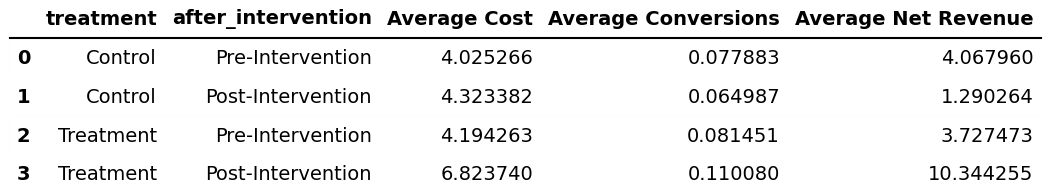

In [ ]:
# average_summary
dfi.export(average_summary, 'average_summary.png',table_conversion='matplotlib')
Image("average_summary.png")

Below table shows the standard deviation in  cost, conversions and the net revenue for each of the (Control and Treatment) group, before and after the intervention:

In [ ]:
std_summary=df.groupby(["treatment","after_intervention"])["cost"].std().reset_index(name="Cost: Standard Deviation").merge(
    df.groupby(["treatment","after_intervention"])["conversions"].std().reset_index(name="Conversions: Standard Deviation"),
    on=["treatment","after_intervention"], how="inner"
).merge(
    df.groupby(["treatment","after_intervention"])["net_revenue"].std().reset_index(name="Net Revenue: Standard Deviation"),
    on=["treatment","after_intervention"], how="inner"
)

std_summary["treatment"].replace({0:"Control", 1:"Treatment"}, inplace=True)
std_summary["after_intervention"].replace({0:"Pre-Intervention", 1:"Post-Intervention"}, inplace=True)

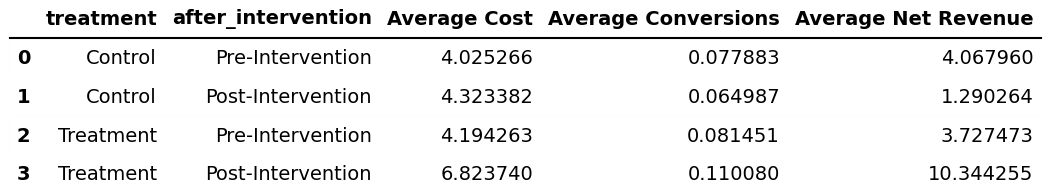

In [ ]:
# std_summary
dfi.export(average_summary, 'std_summary.png',table_conversion='matplotlib')
Image("std_summary.png")

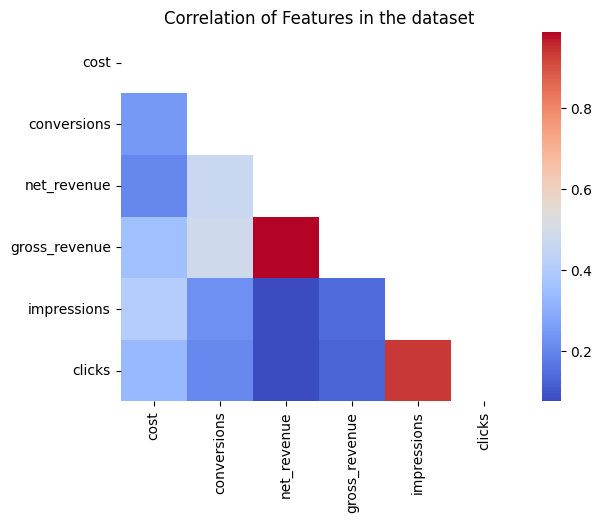

In [ ]:
mask = np.triu(np.ones_like(df.select_dtypes(include='number').corr(), dtype=bool))
sns.heatmap(df.select_dtypes(include='number').corr(),mask=mask, annot=False, cmap='coolwarm')
plt.title("Correlation of Features in the dataset")
plt.show()

From the above heatmap for all features, it is clear that there is a high correlation between gross revenue and net revenue, impressions and clicks. Where as there is some correlation between conversions and net revenue. Some of these correlations are obvious that with higher number of conversions, there is a possibility of higher net revenue.  

* Cost is slightly correlated with conversions, indicating that higher spending leads to slightly more conversions.
* Net revenue and gross revenue are all highly correlated with each other.
* Impressions and clicks are strongly correlated, which is expected as more impressions might lead to more clicks.
* Clicks have a positive correlation with conversions, net revenue, and gross revenue, however there's not a very strong correlation.


In [ ]:
overall_summary = df.groupby(['treatment', 'after_intervention']).agg({
    'cost': 'sum',
    'conversions': 'sum',
    'net_revenue': 'sum',
    'gross_revenue': 'sum',
    'impressions': 'sum',
    'clicks': 'sum'
}).reset_index()
overall_summary['cost_per_conversion'] = overall_summary['cost'] / overall_summary['conversions']
overall_summary['click_through_rate'] = overall_summary['clicks'] / overall_summary['impressions']
overall_summary["treatment"].replace({0:"Control", 1:"Treatment"}, inplace=True)
overall_summary["after_intervention"].replace({0:"Pre-Intervention", 1:"Post-Intervention"}, inplace=True)
overall_summary=overall_summary.round(2)

Adding the Cost per conversion metric and the click through rate for the two groups at pre and post intervention:  

* Cost per conversion: It is the total cost that is required for the total number of conversions for the group.
* Click Through rate: Determines what percentage of people click out of all the impressions that were received.

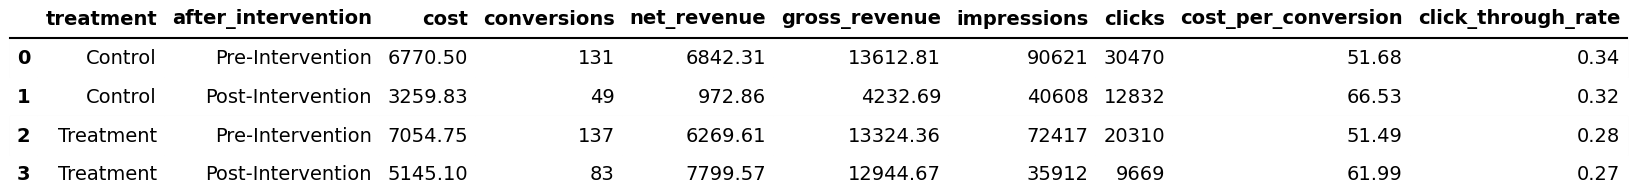

In [ ]:
# overall_summary
dfi.export(overall_summary, 'overall_summary.png',table_conversion='matplotlib')
Image("overall_summary.png")

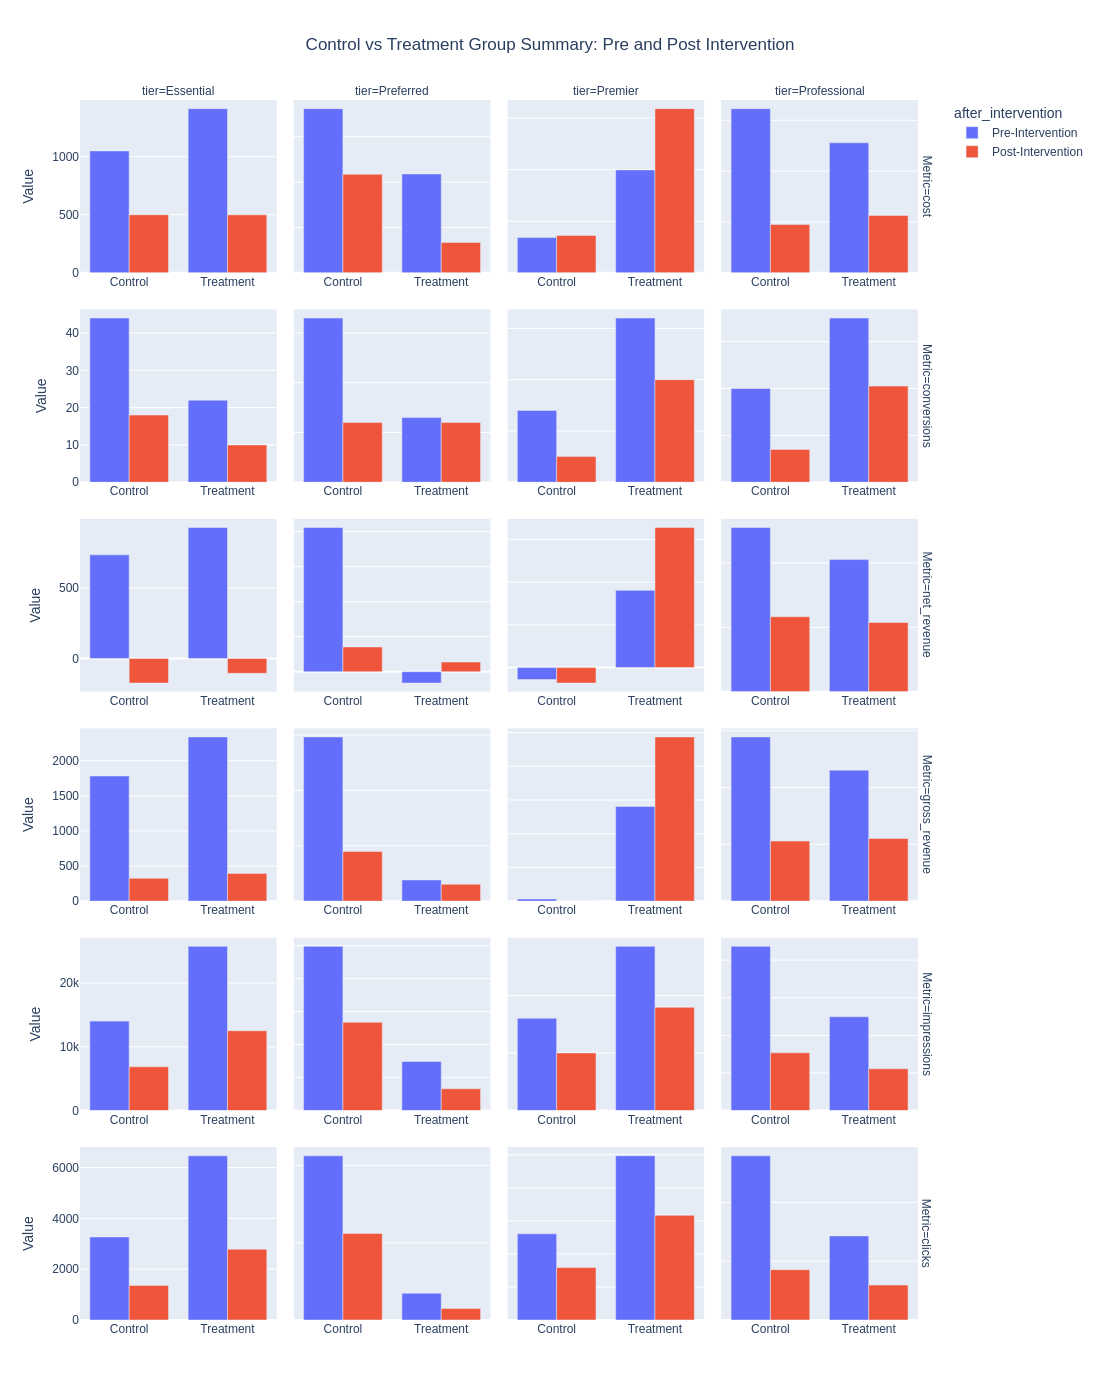

In [ ]:
overall_summary = df.groupby(['tier','treatment', 'after_intervention']).agg({
    'cost': 'sum',
    'conversions': 'sum',
    'net_revenue': 'sum',
    'gross_revenue': 'sum',
    'impressions': 'sum',
    'clicks': 'sum'
}).reset_index()
overall_summary["treatment"].replace({0:"Control", 1:"Treatment"}, inplace=True)
overall_summary["after_intervention"].replace({0:"Pre-Intervention", 1:"Post-Intervention"}, inplace=True)
overall_summary_transformed = overall_summary.melt(id_vars=["tier","treatment", "after_intervention"],
                    value_vars=["cost", "conversions","net_revenue","gross_revenue", "impressions", "clicks"],
                    var_name="Metric",
                    value_name="Value")
fig = px.bar(
    overall_summary_transformed,
    x="treatment",
    y="Value",
    color="after_intervention",
    facet_row="Metric",
    facet_col="tier",
    barmode="group",
    title="Control vs Treatment Group Summary: Pre and Post Intervention",
    width=1100,
    height=1400
)
fig.update_yaxes(matches=None)
fig.update_xaxes(matches=None, title="")
fig.for_each_xaxis(lambda axis: axis.update(showticklabels=True))
fig.update_layout(title_x=0.5)
# fig.show()
fig.write_image("summary_treatment_control.png")
Image("summary_treatment_control.png")

The above visual gives a summary on before/after (Pre-Intervention vs Post-Intervention) comparison across different tiers (Essential, Preferred, Premier, Professional) for each of the metrics that are available.  
We can compare the Control and Treatment group simultaneously, to get some insights on the effect of intervention (tweak to the algorithm) on different metrics.

## Question 1:  
A dataset has already been processed and cleaned, and is ready for you to use in this exercise. However, imagine that in reality, you need to pull and manipulate data yourself. As a data scientist list the data checks you would typically conduct before using data for modeling and analysis to solve the problem at hand. Notes: focus only on the following variables: date, campaignId, cost, conversions, net_revenue and after_treatment. Note: You do NOT need to write code to implement any checks or fix problems and just describe the hypothetical checks you would perform to ensure data quality and readiness for analysis.


Based on the current dataset, if I had to pull and manipulate the data, below are some of the things which I would try to validate before doing the analysis:  

* __Timeline on Data pull__:
  - The data that is available in the dataset is from 2024-09-26 to 2024-11-06, which is about 42 days of data including both; pre-intervention and post-intervention. However, the tweak to the model was made on 2024-10-25, so the data we have for the post-intervention is for about 13 days, whereas the data that is available for pre-intervention is about 29 days. If at all, the data was available for a longer duration post the intervention, I would look for the same.
  - Verify that there are enough campaigns in both treatment and control groups for meaningful comparison.
* __Completeness and Consistency__:
  - Check for any missing values in the dataset, especially the critical ones highlighted: date, campaignId, cost, conversions, net_revenue and after_treatment.
  - Ensure the date values in the data cover the entire expected time range.Also, ensure each campaignId has entries for all days in the dataset.
  - Check for any duplicate values in the dataset.
* __Data type, logical validation and Outliers__:
  - Ensure the date column is in a consistent format and chronological.
  - Check for any campaigns that have activity before the start date or after the end date of the experiment.
  - The field campaignId is a unique on a particular date.
  - Ensure the fields cost, conversions and net_revenue are numeric.
  - Identify any unusually high or low values in cost, conversions, and net_revenue.
  - The field cost cannot be negative, whereas the field net_revenue could be negative, as there could be no gross revenue on a particular day.
  - Verify that net_revenue is consistent with conversions (for example, net_revenue should not be positive if there are no conversions).
  - Ensure that the after_treatment variable changes from 0 to 1 at the expected intervention date. Confirm that after_treatment only contains 0 and 1 values.
* __Data Distribution, Correlation__:
  - Examine the distribution of cost, conversions, and net_revenue for normality or expected patterns.
  - Sense check on the correlation of the variables, (for example: impressions and clicks should usually have a positive correlation, same with net_revenue and gross_revenue). This is optional but not always necessary.

## Question 2:  
Plot a time series of the three performance metrics for the test and control campaigns for both the before and after periods with a clear demarcation for the date of intervention (i.e. the first day when the algorithm was tweaked)

Creating a summary dataframe for plotting the time series of the three metrics over time. Because we have other variables like: region, tier in the dataset which may have some differences in each of the values in those variables. The values within these variables are used as a Trellis in the Time series plot below. Note: The field region has just one value for entire dataset, which could be ignored for this and just the tier field could be used in the Trellis chart

In [ ]:
overall_metrics=df.groupby(["date","treatment","after_intervention"])["cost"].mean().reset_index(name="cost").merge(
    df.groupby(["date","treatment","after_intervention"])["conversions"].mean().reset_index(name="conversions"),
    how="inner",on=["date","treatment","after_intervention"]).merge(
    df.groupby(["date","treatment","after_intervention"])["net_revenue"].mean().reset_index(name="net_revenue"),
    how="inner",on=["date","treatment","after_intervention"])
overall_metrics.dropna(subset=['cost', 'conversions', 'net_revenue'], how='all',inplace=True)
overall_metrics.reset_index(drop=True, inplace=True)
overall_metrics["treatment"].replace({0:"Control", 1:"Treatment"}, inplace=True)
overall_metrics["after_intervention"].replace({0:"Pre-Intervention", 1:"Post-Intervention"}, inplace=True)
overall_metrics=overall_metrics.round(3)
def get_overall_timeseries(metric):
    fig = px.line(
        overall_metrics,
        x="date",
        y=overall_metrics[metric],
        color="treatment",
        hover_data={"date": "|%B %d, %Y"},
        title=f"Average Daily {metric.title()} per Campaign",
        labels={'value': 'Daily Average per Campaign', 'date': 'Date'}
    )

    intervention_start_date = overall_metrics[overall_metrics["after_intervention"] == "Post-Intervention"]["date"].min()
    fig.add_shape(
        type="line",
        x0=intervention_start_date,
        x1=intervention_start_date,
        y0=0,
        y1=1,
        xref="x",
        yref="paper",
        line=dict(color="gray", width=2, dash="dot"),
    )

    fig.add_trace(
        dict(
            x=[None],
            y=[None],
            mode="lines",
            line=dict(color="gray", width=2, dash="dot"),
            name="Algorithm Changed"
        )
    )

    fig.update_traces(
        mode='lines+markers',
        marker=dict(size=4, symbol='circle')
    )
    fig.update_layout(
        width=1250,
        height=350,
        showlegend=True,
        legend_title_text=""
    )

    fig.add_annotation(
        x=intervention_start_date,
        y=1,
        text=f"Algorithm Changed ({intervention_start_date.date()})",  # Text to display
        showarrow=True,
        xref="x",
        yref="paper",
        font=dict(size=12, color="gray"),
        align="center"
    )
    fig.update_layout(title_x=0.5)
    # fig.show()
    fig.write_image(f"{metric}.png")
    return Image(f"{metric}.png")

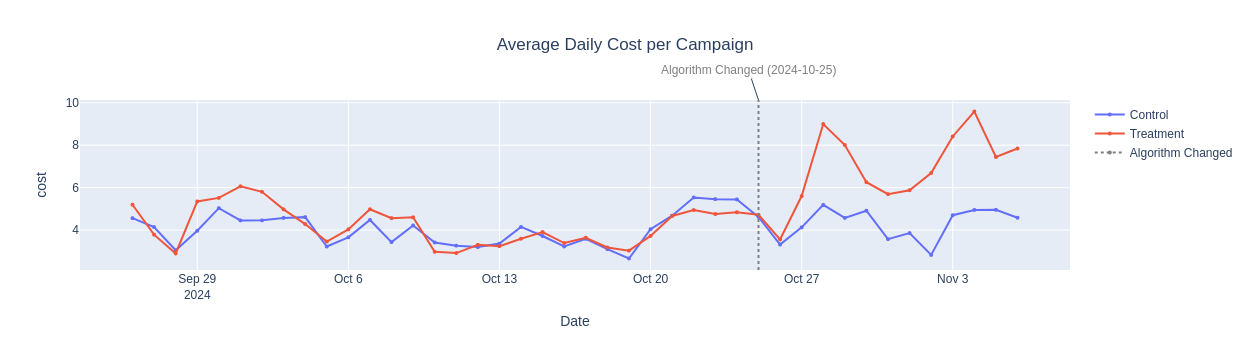

In [ ]:
get_overall_timeseries("cost")

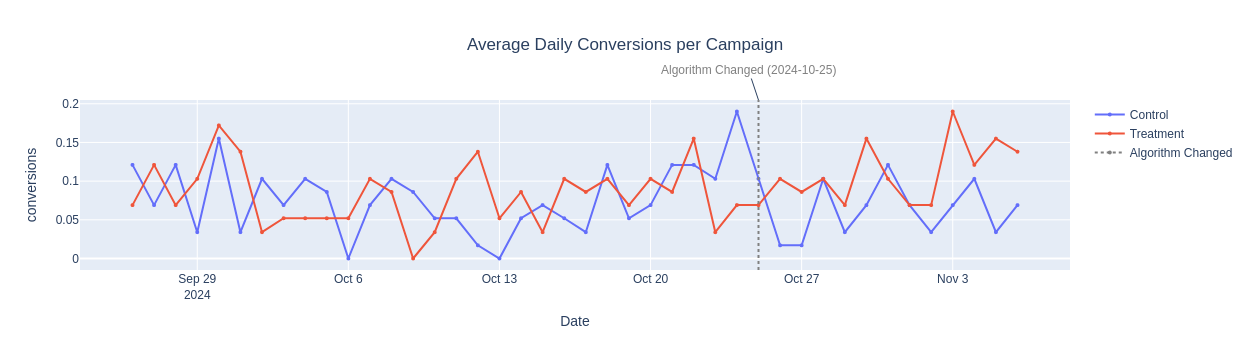

In [ ]:
get_overall_timeseries("conversions")

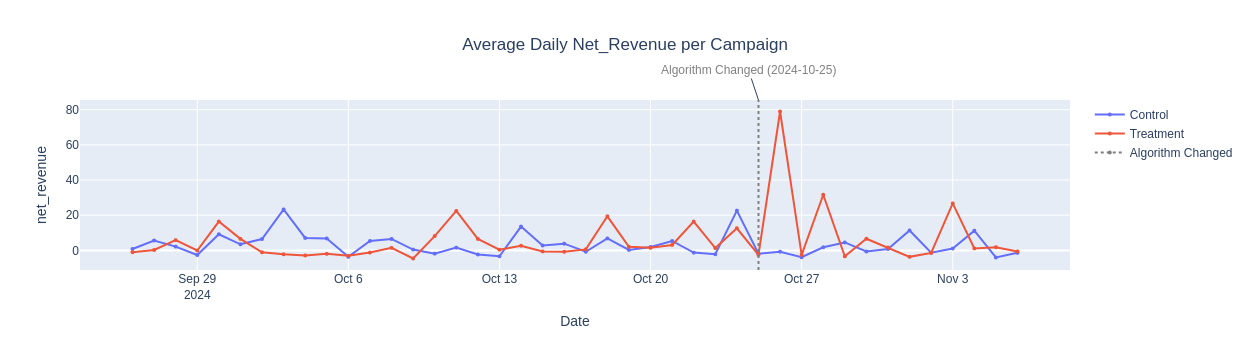

In [ ]:
get_overall_timeseries("net_revenue")

In [ ]:
campaign_metrics=df.groupby(["date","treatment","tier","after_intervention"])["cost"].mean().reset_index(name="cost").merge(
    df.groupby(["date","treatment","tier","after_intervention"])["conversions"].mean().reset_index(name="conversions"),
    how="inner",on=["date","treatment","tier","after_intervention"]).merge(
    df.groupby(["date","treatment","tier","after_intervention"])["net_revenue"].mean().reset_index(name="net_revenue"),
    how="inner",on=["date","treatment","tier","after_intervention"])
campaign_metrics.dropna(subset=['cost', 'conversions', 'net_revenue'], how='all',inplace=True)
campaign_metrics.reset_index(drop=True, inplace=True)
campaign_metrics = campaign_metrics.melt(id_vars=["date","tier","treatment", "after_intervention"],
                                     value_vars=["cost", "conversions", "net_revenue"],
                                     var_name="metric",
                                     value_name="value")
campaign_metrics["treatment"].replace({0:"Control", 1:"Treatment"}, inplace=True)
campaign_metrics["after_intervention"].replace({0:"Pre-Intervention", 1:"Post-Intervention"}, inplace=True)
campaign_metrics=campaign_metrics.round(3)
def get_trendline_for_metrics(metric):
    fig = px.line(
        campaign_metrics[campaign_metrics["metric"]==metric],
        x="date",
        y="value",
        color="treatment",
        facet_row="tier",
        hover_data={"date": "|%B %d, %Y"},
        title=f"Average Daily {metric.title()} per Campaign",
        labels={'value': 'Daily Avg. per Campaign', 'date': 'Date'}
    )

    intervention_start_date = campaign_metrics[campaign_metrics["after_intervention"] == "Post-Intervention"]["date"].min()
    fig.add_shape(
        type="line",
        x0=intervention_start_date,
        x1=intervention_start_date,
        y0=0,
        y1=1,
        xref="x",
        yref="paper",
        line=dict(color="gray", width=2, dash="dot"),
    )

    fig.add_trace(
        dict(
            x=[None],
            y=[None],
            mode="lines",
            line=dict(color="gray", width=2, dash="dot"),
            name="Algorithm Changed"
        )
    )

    fig.update_traces(
        mode='lines+markers',
        marker=dict(size=4, symbol='circle')
    )
    fig.update_layout(
        width=1400,
        height=1000,
        showlegend=True,
        legend_title_text=""
    )

    fig.add_annotation(
        x=intervention_start_date,
        y=1,
        text=f"Algorithm Changed ({intervention_start_date.date()})",  # Text to display
        showarrow=True,
        xref="x",
        yref="paper",
        font=dict(size=12, color="gray"),
        align="center"
    )

    fig.update_yaxes(matches=None)
    fig.update_layout(title_x=0.5)
    # fig.show()
    fig.write_image(f"{metric}.png")
    return Image(f"{metric}.png")

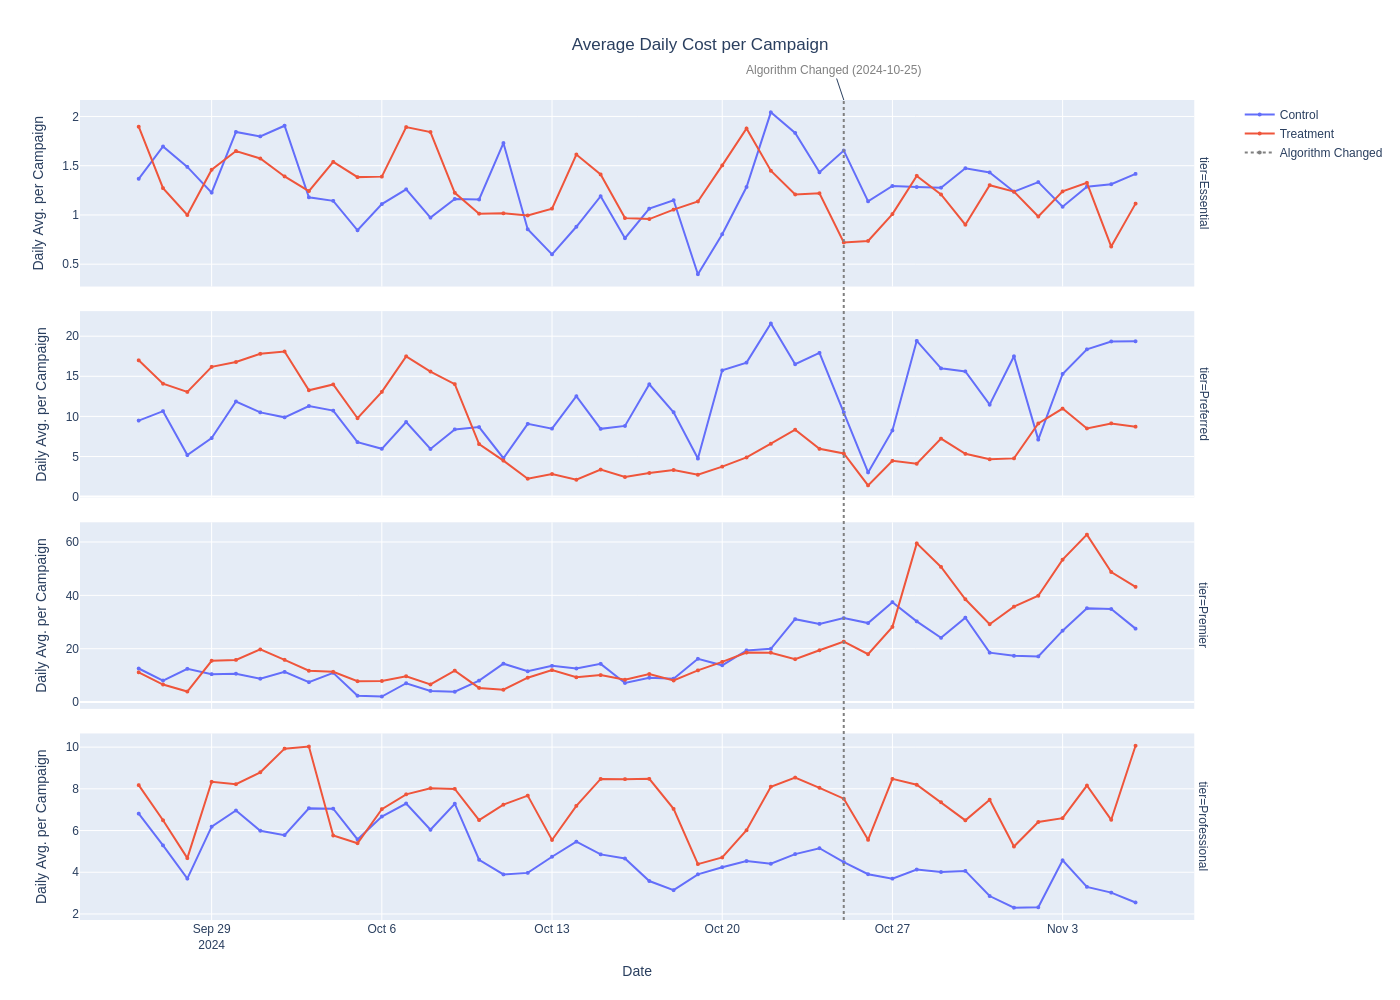

In [ ]:
get_trendline_for_metrics("cost")

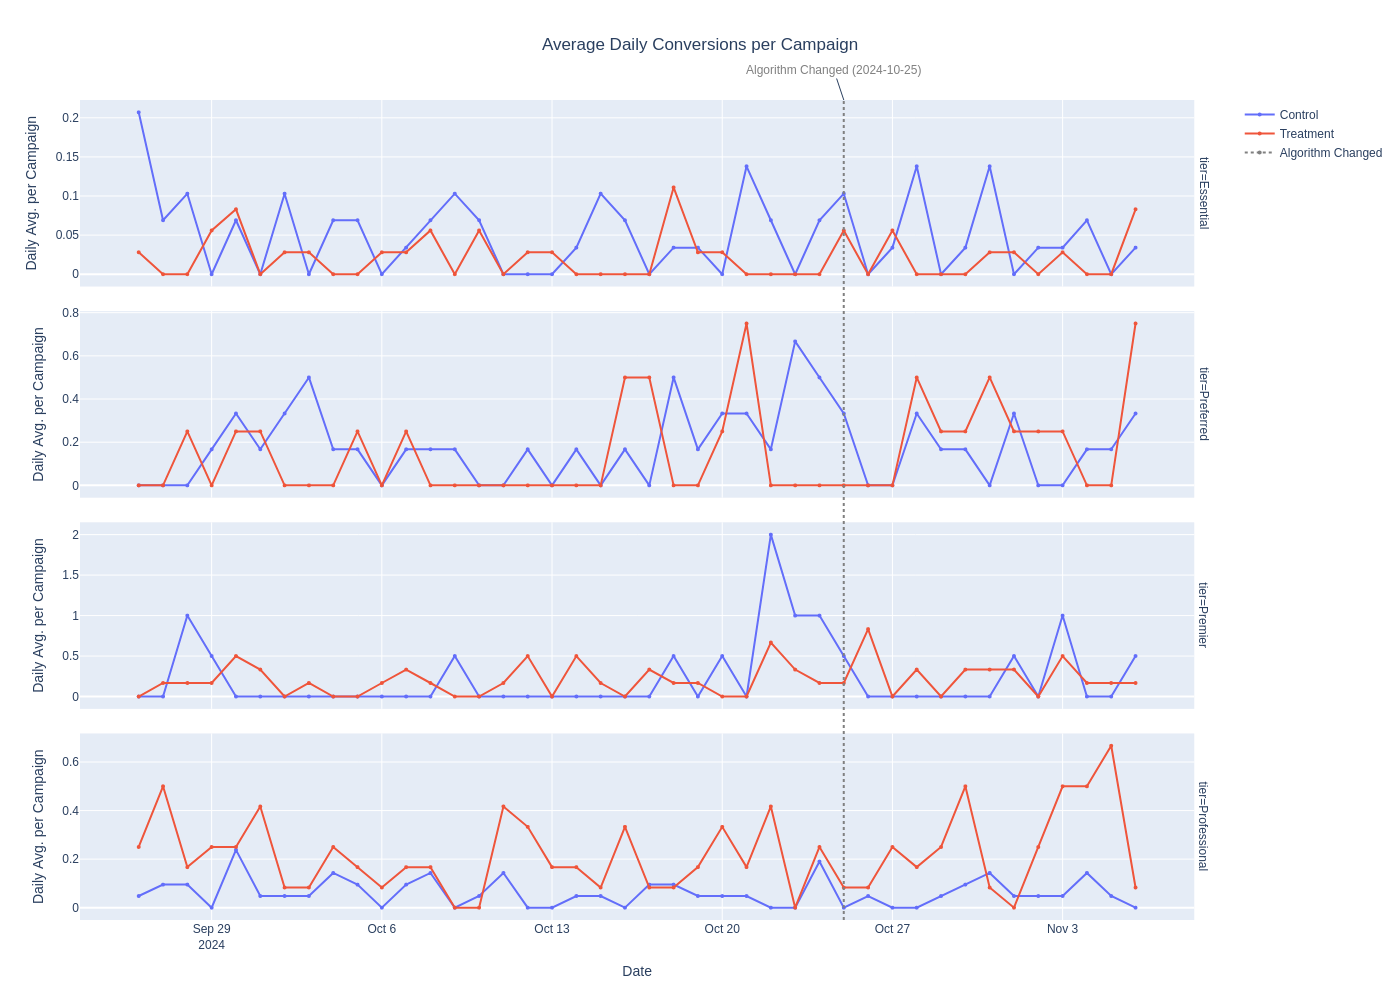

In [ ]:
get_trendline_for_metrics("conversions")

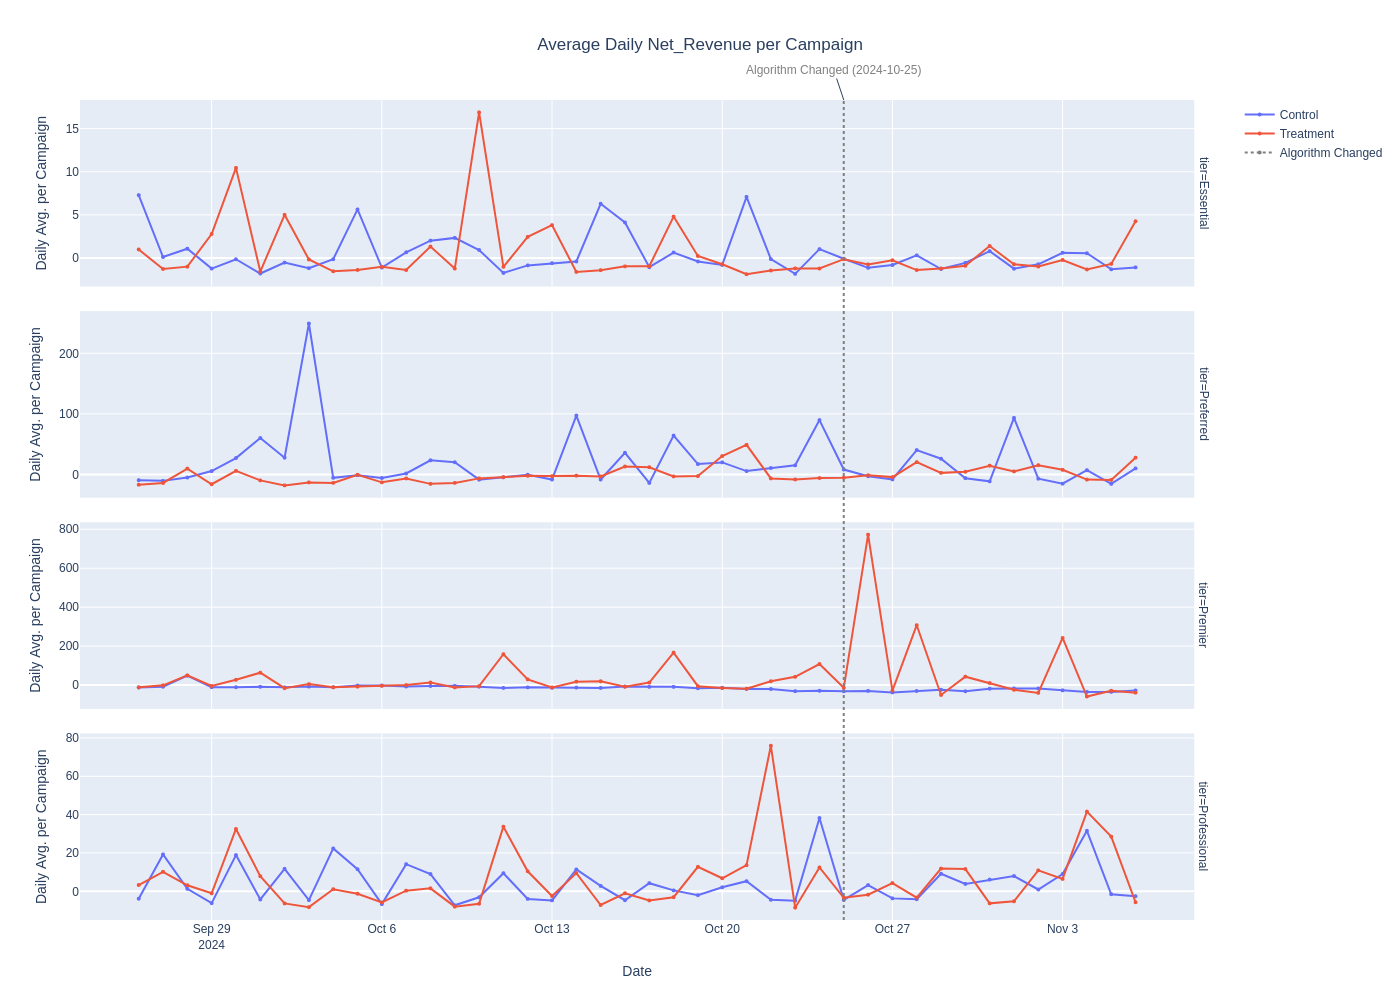

In [ ]:
get_trendline_for_metrics("net_revenue")

## Question 3:  
To proceed with data analysis to causally estimate the impact of the tweak to the algorithm, what criteria need to be met for the two groups in the pre-intervention period?

To causally estimate of the impact of a treatment(tweak to the algorithm) in our use case, the two groups in the pre-intervention period should meet the following criteria:

* __Parallel Trends Assumption__:
  - The two groups should show parallel trends in the outcome variables during the pre-intervention period. In this case, the outcome of interest are cost, conversions and net_revenue. Considering this assumption, each of the metric cost, conversion and net_revenue metric individually should have a similar trends in the two groups. For example: The metric cost should have a similar trend within control and treatment, similarly for conversion and net_revenue this assumption should be met for the two groups.
  - This the most crucial assumption, that the treatment and control groups would have followed parallel trends in the outcome variable if the treatment had not occurred.
* __Comparability__:
The two groups control and treatment should be comparable in terms of the observed characteristics and the outcomes (which is outcomes before the intervention).  
* __No Other Confounding Intervention__:
There are no other intervention or events during the pre-intervention period that differentially affects the treatment and control groups.

## Question 4:
Provide evidence for whether (or not) the criteria you have identified in Question 3 are being met using the dataset provided to you. Also provide the justification in words the method you have chosen to draw evidence.

### **Parallel Trends Assumption**  
To validate this assumption, we can use different approaches, out of which I have explore the below:  

#### 1. **Visual Inspection:**
   * The plot for outcomes of in Question 2 can be observed for the trend in both the groups for each of the metrics separately before the intervention period. We can observe the below chart for the cost metric (the trend line for treatment and control groups) before the intervention period (grey dotted line). Both the trend lines follow a very similar trend before the interevention which was on 2024-10-25. This suggests that the parallel trend assumption holds reasonably well in the pre-intervention period. The trend line shows the average cost for all the campaigns in each of those groups on that particular day.

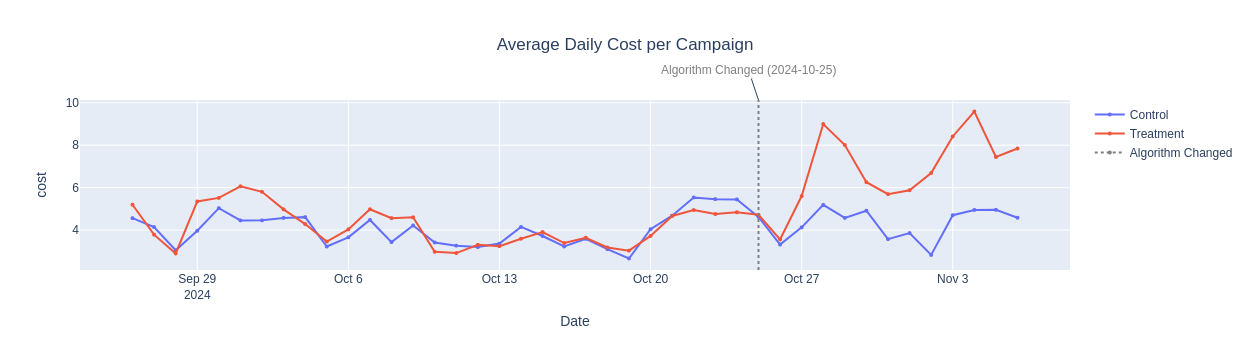

In [ ]:
get_overall_timeseries("cost")

* Similarly, we can also observe the trend line for the other two metrics of interest which is net_revenue and conversions.

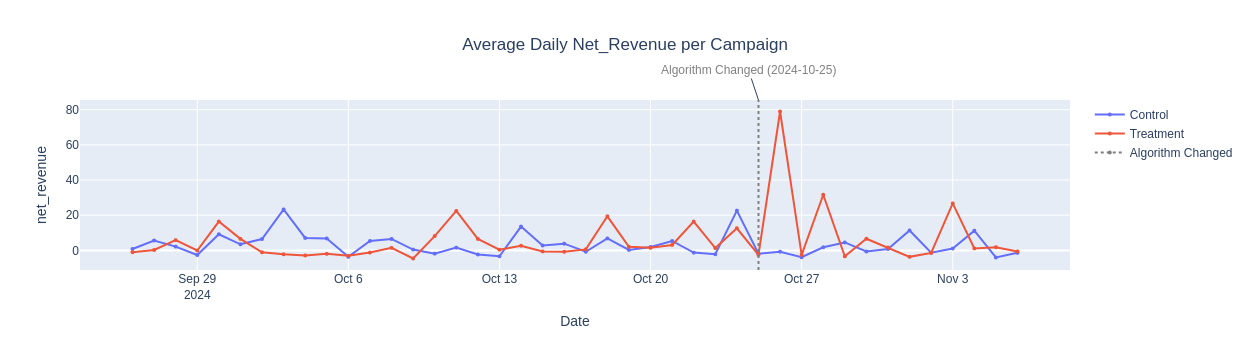

In [ ]:
get_overall_timeseries("net_revenue")

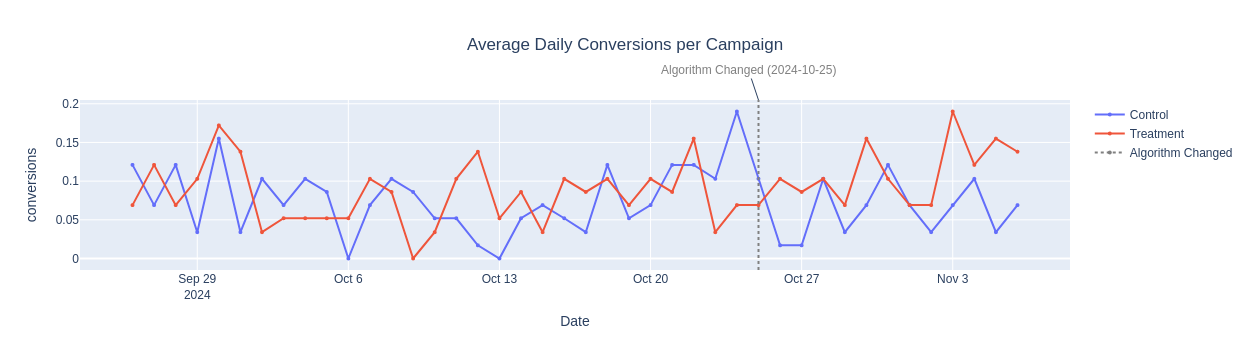

In [ ]:
get_overall_timeseries("conversions")

* From inspecting the trend line for net_revenue and conversions, the trend line in each of the group for both the metrics follows a similar pattern/trend on most of the days, however there are very slight mismatch in the trend in certain ocassions. The trends for the control and treatment groups appear to fluctuate but do not show a clear, consistent parallel pattern. There are periods where the lines diverge and converge, which might suggest that the parallel trends assumption may not hold perfectly.
* To further validate if the Parallel Trends assumption holds true we will conduct a statistical test usnig a regression model.

#### 2. __Regression Model to test for Parallel Trends assumption:__  
We could potentially conduct the regression model for only the conversions and the net_revenue metric as the assumption held reasonably well for the cost metric.

The regression model for each metric (cost, conversions and net_revenue) is: ___`metric` ~ time + treatment + (time * treatment)___

* Dependent variable: The metric being tested (cost, conversion, or net_revenue)
* Independent variable:
  - `time`: A continous variable representing time in the pre-intervention period.
  - `treatment`: A binary indicator (1=Treatment group, 0=control group).
  - `time:treatment`: The interaction term to test if the trends differ between the treatment and control group.  

Hypothesis for the interaction term:

* Null Hypothesis (Ho): The coefficient of the interaction term (`time:treatment`) is zero, indicating parallel trends.
* Alternative Hypothesis (Ha): The coefficient of the interaction term (`time:treatment`) is non-zero, indicating violation of parallel trends.

In [ ]:
import statsmodels.formula.api as smf
pre_intervention_data = df[df['after_intervention'] == 0].copy()

pre_intervention_data['time'] = (pre_intervention_data['date'] - pre_intervention_data['date'].min()).dt.days

def test_parallel_trends(data, metric):
    formula = f"{metric} ~ time + treatment + time:treatment"

    model = smf.ols(formula=formula, data=data).fit()

    print(f"Regression Test results for the metric- {metric}:")
    print(model.summary())
    print("\n")

In [ ]:
test_parallel_trends(pre_intervention_data, "conversions")

Regression Test results for the metric- conversions:
                            OLS Regression Results                            
Dep. Variable:            conversions   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.1150
Date:                Thu, 26 Dec 2024   Prob (F-statistic):              0.951
Time:                        23:59:57   Log-Likelihood:                -1168.8
No. Observations:                3364   AIC:                             2346.
Df Residuals:                    3360   BIC:                             2370.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------

Lets review the results of the Regression model for the metric conversions:

* The intercept of the model is _0.0713_, which is the baseline average conversions for the control group at the start of the intervention period.
* The key value from the model that is of our interest is the interaction term: `time:treatment`, which has the intercept of _-0.0007_, which is the difference in trends between the group. The p-value for the same is not statistically significant (_p=0.643_). This suggests that there is no evidence of difference in the trends between the treatment and control group. We have failed to reject the null hypothesis.
* **Hence, the parallel trends hold for the metric conversions**

In [ ]:
test_parallel_trends(pre_intervention_data, "net_revenue")

Regression Test results for the metric- net_revenue:
                            OLS Regression Results                            
Dep. Variable:            net_revenue   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.6380
Date:                Thu, 26 Dec 2024   Prob (F-statistic):              0.591
Time:                        23:59:57   Log-Likelihood:                -18245.
No. Observations:                3364   AIC:                         3.650e+04
Df Residuals:                    3360   BIC:                         3.652e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------

Lets review the results of the Regression model for the metric net_revenue:

* The intercept of the model is _4.2715_, which is the baseline average net_revenue for the control group at the start of the intervention period.
* The key value from the model that is of our interest is the interaction term: `time:treatment`, which has the intercept of _0.2335_, which is the difference in trends between the groups. The p-value for the same is not statistically significant (_p=0.302_). This suggests that there is no evidence of difference in the trends between the treatment and control group. We have failed to reject the null hypothesis.
* **Hence, the parallel trends hold for the metric net_revenue**

If we conduct the same test for the cost metric just to validate our Parallel trends statistically, instead of just observation, we can see the results below:

In [ ]:
test_parallel_trends(pre_intervention_data, "cost")

Regression Test results for the metric- cost:
                            OLS Regression Results                            
Dep. Variable:                   cost   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.6592
Date:                Thu, 26 Dec 2024   Prob (F-statistic):              0.577
Time:                        23:59:57   Log-Likelihood:                -12067.
No. Observations:                3364   AIC:                         2.414e+04
Df Residuals:                    3360   BIC:                         2.417e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------

Lets review the results of the Regression model for the metric cost:

* The intercept of the model is _3.9236_, which is the baseline average cost for the control group at the start of the intervention period.
* The key value from the model that is of our interest is the interaction term: `time:treatment`, which has the intercept of _-0.0393_, which is the difference in trends between the groups. The p-value for the same is not statistically significant _(p=0.275)_. This suggests that there is no evidence of difference in the trends between the treatment and control group. We have failed to reject the null hypothesis.
* __Hence, the parallel trends hold true for the metric cost__.

#### **Parallel Trend Assumptions summary**<br>


Based on the above Regression model results for all the metrics and the observation of the trendline for the metric cost, __we can assume that the parallel trends assumption holds true for all the metrics with statistical significance.__  
The reason that a regression model would be suitable in this case is:

* The regression model allows us to add an interaction term (`time:treatment`), which directly tests whether the trend over the time differs between the treatment and control variable.
* The p-value for the interaction term gives us a formal test of whether the differences in the groups are statistically significant.
* Regression models usually handle the data well to provide robust results even with variability in observation, as in our case for the conversions and net_revenue metric where it was not evident from the observation whether the parallel trend assumption would hold true.

### **Comparability of the the groups:**

To compare the Treatment and Control groups in the pre-intervention period, we can calculate the mean values for the metrics cost, conversions and net_revenue and perform a t-test to check for statistical significant differences.  

* Null Hypothesis (Ho): The mean values for the metrics cost, conversions and revenue in the treatment and control group are equal.
* Alternative Hypothesis (Ha): The mean values for the metrics cost, conversions and revenue in the treatment and control group are not equal.

In [ ]:
from scipy.stats import ttest_ind

treatment_group = pre_intervention_data[pre_intervention_data['treatment'] == 1]
control_group = pre_intervention_data[pre_intervention_data['treatment'] == 0]

results = {}
for metric in ['cost', 'conversions', 'net_revenue']:
    t_stat, p_value = ttest_ind(treatment_group[metric], control_group[metric], equal_var=False)
    results[metric] = {'t_stat': t_stat, 'p_value': p_value}

print("T-Test Results:")
for metric, result in results.items():
    print(f"{metric.capitalize()}: t-statistic = {result['t_stat']:.4f}, p-value = {result['p_value']:.4f}")

T-Test Results:
Cost: t-statistic = 0.5604, p-value = 0.5753
Conversions: t-statistic = 0.3019, p-value = 0.7627
Net_revenue: t-statistic = -0.1799, p-value = 0.8572


Based on the above results for a t-test for the means comparison of the two groups, we can conclude that we have failed to reject the null hypothesis, as the value for each of the metric is below 0.05 We can conclude that the two groups are comparable.  
However, there is an additional variable in our dataset, which is `tier` we have seen in the additional trend line with a trellis chart in Question 2, that there has been some difference in the metrics in different values for tiers. We could do a Chi-square contingency test to compare the balance of the variable tier within the two groups.

To conduct a Chi-square contingency test, below is the test setup:

* Null Hypothesis (Ho): The tier variable is independent of the treatment variable.
* Alternative Hypothesis (Ha): The tier variable is not independent of the treatment variable.

In [ ]:
from scipy.stats import chi2_contingency
contingency_table = pd.crosstab(pre_intervention_data['tier'], pre_intervention_data['treatment'])
chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)
print("Contingency Table:")
print(pd.DataFrame(contingency_table).T)
print("\nChi-Square Test Results:")
print(f"Chi-Square Statistic: {chi2_stat:.4f}")
print(f"P-Value: {p_value:.4e}")
print(f"Degrees of Freedom: {dof}")

Contingency Table:
tier       Essential  Preferred  Premier  Professional
treatment                                             
0                841        174       58           609
1               1044        116      174           348

Chi-Square Test Results:
Chi-Square Statistic: 162.6434
P-Value: 4.9277e-35
Degrees of Freedom: 3


Based on the results for the chi-square test, we can reject the null hypothesis, with the p-value far below significance level (_p<0.05_) and the chi-square statistics is ___162.6434___.  
Considering the derived fact that there is a significant association of the variable tier with the treatment variable. This could potentially act as a confounding variable when we are further evaluating the causal estimates. It is necessary to account for the variable tier in any causal inference analysis to avoid confounding effects.


## Question 5:
Analyze the dataset to assess if there was any impact of the intervention(i.e. tweak to the algorithm) on the three performance metrics. Provide justification for the methodology that you have used to assess the impact of the intervention. Feel free to be creative with the methodology as long as it is statistically/methodologically valid.

The goal is to determine whether the intervention had a statistically significant impact on the performance metrics. This involves comparing the treatment group (campaigns with the tweak) to the control group (campaigns without the tweak) both before and after the intervention date (October 25, 2024).  
To evaluate whether the intervention (algorithm tweak) had an impact on the three performance metrics: cost, conversions and net_revenue, we could use the Difference-in-Differences methodology.  
The Difference-in-Differences methodology is appropriate as it compares the changes in the outcomes over time between the Treatment and Control group. This method accounts for:

* Time-invariant differences between the two groups.
* Both the groups would have followed similar trends in the absence of the intervention, which we have identified from Question 4. (Parallel Trends Assumption)
* This method also allows us to handle the effect on the outcome variable due potential confounding variable present in the data, which is tier variable in our case as seen in the above Question 4, when comparing the two groups.
* We will be implementing a Regression method to estimate the impact of the intervention on each of the metric of interest. Using a regression model is effective for multiple reasons:
   - With the regression model we can explicitly include the interaction term that represents the causal effect of the intervention, which would quantify how the outcome changes for the treatment group after the interevention relative to the control group.
   - Provide ability to adjust for confounding variables, as we do have a potential confounding variable tier for which we would need to account for.
   - The model would give results to utilise the statistical significance like: p-value, t-statistics for each coefficient.

As we have seen earlier in the Exploratory Data Analysis, there is a high correlation in net_revenue and gross_revenue, which is obvious due to the fact that net_revenue is gross revenue - cost. Also there is a high-correlation between impressions and clicks. We could potentially, remove the variable gross_revenue when building the model.  
We only need to focus on the causal impact of the treatment(tweak in algorithm) post-intervention. Only variables/factors which are important to us:

* cost
* conversions
* net_revenue
* treatment
* after_intervention
* tier (As this variable shows significant association with the treatment variable)  

Below are the general assumptions for all the below regression models for Differences-in-differences:

* The parallel trends assumptions holds true as seen in Question 4.
* Given that there is no additional data, we can assume there is no additional confounding event or intervention that occurs simultaneously with the current intervention on either of the groups. (except the tweak to the algorithm).
* Consistency in the campaigns composition. The treatment and control campaigns remain consistent over the time.

In [ ]:
def regression_model(formula):
    model = smf.ols(formula=formula, data=df).fit(cov_type='HC1')
    print(model.summary())

#### Impact on the metrics

The A/B test was specifically set-up to evaluate the impact of the tweak to the back-end algorithm on the three key performance metrics- cost, conversions, and net-revenue. At the start we can use a simple model to find the causal impact of the algorithm tweak

In [ ]:
import numpy as np
aggregated = df.groupby(['treatment', 'after_intervention']).agg({
    'net_revenue': ['mean', 'var', 'count'],
    'cost': ['mean', 'var', 'count'],
    'conversions': ['mean', 'var', 'count']
}).reset_index()
aggregated.columns = ['treatment', 'after_intervention',
                      'net_revenue_mean', 'net_revenue_var', 'net_revenue_count',
                      'cost_mean', 'cost_var', 'cost_count',
                      'conversions_mean', 'conversions_var', 'conversions_count']

def calculate_did_and_se(data, metric):
    treated_post = data[(data['treatment'] == 1) & (data['after_intervention'] == 1)]
    treated_pre = data[(data['treatment'] == 1) & (data['after_intervention'] == 0)]
    control_post = data[(data['treatment'] == 0) & (data['after_intervention'] == 1)]
    control_pre = data[(data['treatment'] == 0) & (data['after_intervention'] == 0)]

    treated_diff = treated_post[f"{metric}_mean"].values[0] - treated_pre[f"{metric}_mean"].values[0]
    control_diff = control_post[f"{metric}_mean"].values[0] - control_pre[f"{metric}_mean"].values[0]
    did_estimate = treated_diff - control_diff

    se = np.sqrt(
        treated_pre[f"{metric}_var"].values[0] / treated_pre[f"{metric}_count"].values[0] +
        treated_post[f"{metric}_var"].values[0] / treated_post[f"{metric}_count"].values[0] +
        control_pre[f"{metric}_var"].values[0] / control_pre[f"{metric}_count"].values[0] +
        control_post[f"{metric}_var"].values[0] / control_post[f"{metric}_count"].values[0]
    )

    return did_estimate, se

metrics = ['net_revenue', 'cost', 'conversions']
results = {}
for metric in metrics:
    did_estimate, se = calculate_did_and_se(aggregated, metric)
    results[metric] = {'DiD Estimate': did_estimate, 'Standard Error': se}

In [ ]:
did_results=pd.DataFrame(results)

__From the above, we can see there is an impact of the intervention (tweak in the algorithm) on the treatment group to increase the average daily net revenue by about 9.394, an increase in average daily cost by about 2.331 and an increase in average daily conversions by about 0.041__  
However the above results does not consider the effect other variables could have on these metrics, nor does it have a statistical significance of the estimate. We will conduct a t-test on the outcomes from the differences-in-differences calculation.  
We can further implement a regression model for each of the metric to find a statistical significance for this impact.

In [ ]:
from scipy.stats import t
print("Detailed Interpretation of DiD Results:")

metrics = ['net_revenue', 'cost', 'conversions']
for metric in metrics:
    estimate = did_results.loc['DiD Estimate', metric]
    se = did_results.loc['Standard Error', metric]
    t_stat = estimate / se
    p_value = 2 * (1 - t.cdf(abs(t_stat), df=len(df) - 4))

    print(f"\n{metric.capitalize()}:")
    print(f"Estimate: {estimate:.4f}")
    print(f"Standard Error: {se:.4f}")
    print(f"t-statistic: {t_stat:.4f}")
    print(f"p-value: {p_value:.4f}")

    if p_value < 0.05:
        print("The effect is statistically significant at the 5% level.")
        if estimate > 0:
            print(f"The algorithm tweak led to a significant increase in {metric}.")
        else:
            print(f"The algorithm tweak led to a significant decrease in {metric}.")
    else:
        print(f"The effect on {metric} is not statistically significant at the 5% level.")

    print(f"The algorithm tweak resulted in a change of {estimate:.2f} in {metric}, "
          f"with a standard error of {se:.2f}.")

Detailed Interpretation of DiD Results:

Net_revenue:
Estimate: 9.3945
Standard Error: 7.3381
t-statistic: 1.2802
p-value: 0.2005
The effect on net_revenue is not statistically significant at the 5% level.
The algorithm tweak resulted in a change of 9.39 in net_revenue, with a standard error of 7.34.

Cost:
Estimate: 2.3314
Standard Error: 1.2506
t-statistic: 1.8643
p-value: 0.0623
The effect on cost is not statistically significant at the 5% level.
The algorithm tweak resulted in a change of 2.33 in cost, with a standard error of 1.25.

Conversions:
Estimate: 0.0415
Standard Error: 0.0225
t-statistic: 1.8472
p-value: 0.0648
The effect on conversions is not statistically significant at the 5% level.
The algorithm tweak resulted in a change of 0.04 in conversions, with a standard error of 0.02.


We will now implement a regression model to consider additional confounding factors, one of which is important considering the results from the chi-square testing for comparability of the two groups.

The regression model includes tier as a control variable in the regression model, which helps to control for the systematic differences between the 4 categories in tiers.  
This considers heterogeneous effects of different tiers of the campaigns.<br>
An alternative approach would have been using Propensity score matching, however, with data available for analysis, it might be helpful to presever full samples using systematic and also observe tier-specific differences.  
Other variables like clicks, impressions, gross_revenue are excluded from the analysis, primarliy because we want to emphasize only on the impact of the intervention(tweak) and also including them caused multicollinearity in some cases which was tested using the Variance Inflation Factor (VIF).


In [ ]:
formula_cost = """cost ~ treatment + treatment:after_intervention + C(tier)"""
regression_model(formula_cost)

                            OLS Regression Results                            
Dep. Variable:                   cost   R-squared:                       0.114
Model:                            OLS   Adj. R-squared:                  0.113
Method:                 Least Squares   F-statistic:                     95.13
Date:                Thu, 26 Dec 2024   Prob (F-statistic):          2.11e-113
Time:                        23:59:58   Log-Likelihood:                -19816.
No. Observations:                4872   AIC:                         3.965e+04
Df Residuals:                    4865   BIC:                         3.969e+04
Df Model:                           6                                         
Covariance Type:                  HC1                                         
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------


* The model explains 11.4% of the variance in the costs, suggesting there could be other factors that also influence the cost. The primary goal the model is to understand the direction and significance of the relationship between the outcome variables and the treatment/intervention (tweak to the algorithm) effect, also considering the available confounding variable, so the lower R-squared value here should not be much of concern.
* `treatment`: The presence of a campaign in either the control or treatment group does not have any statistical signficance effect on the cost. _(p=0.828)_
* `tier` effects: Compared to the baseline (Essential tier), all other tiers significantly increase the costs, with highest coeffiecient by the Premier tier, and all of them having p-value lower than _(p<0.05)_. Especially, the campaigns in the Premier tier seem to have a very high impact on the cost
* Higher tiers are associated with higher cost compared to the essential tier.
* `treatment:after_intervention`: The interaction term between treatment and after_intervention is statistically signficant. This is causal estimate of the intervention on the cost for the treatment group. The coefficient of 2.6295 for the interaction term suggests that after intervention, the cost for the treatment group increases by about 2.6295 units compared to the period before the intervention. These results are statistically significant for the treatment group _(p=0.016)_. Whereas for the control group it is much lower, however it does not have a statistical significance.
* Overall we can conclude that the intervention (tweak in the algorithm) has caused a slight increase in the cost to the Treatment group and it is statistically significant.

In [ ]:
formula_conversions = """conversions ~ treatment + treatment:after_intervention + C(tier) """
regression_model(formula_conversions)

                            OLS Regression Results                            
Dep. Variable:            conversions   R-squared:                       0.030
Model:                            OLS   Adj. R-squared:                  0.028
Method:                 Least Squares   F-statistic:                     17.37
Date:                Thu, 26 Dec 2024   Prob (F-statistic):           5.53e-20
Time:                        23:59:58   Log-Likelihood:                -1751.0
No. Observations:                4872   AIC:                             3516.
Df Residuals:                    4865   BIC:                             3561.
Df Model:                           6                                         
Covariance Type:                  HC1                                         
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------


* The model explains 3% of the variance in the conversions, suggesting there could be other factors that also influence the conversions. The primary goal the model is to understand the direction and significance of the relationship between the outcome variables and the treatment/intervention (tweak to the algorithm) effect, also considering the available confounding variable, so the lower R-squared value here should not be much of concern.
* `treatment`: The presence of a campaign in either the control or treatment group does not have much statistical signficance effect on the conversions. _(p=0.407)_
* `tier` effects: The coefficients suggest that campaigns in the higher-tier impacts and results in higher conversions, consistent with expectations that premier campaigns are more likely to have higher conversions. Compared to the baseline (Essential tier), all other tiers increase the average daily conversions with highest coeffiecient by the Premier tier, and all of them having p-value lower than 0.05
* `treatment:after_intervention`: The interaction term between treatment and after_intervention is not statistically signficant. This is causal estimate of the intervention on the conversion for the treatment group. The slightly higher p-value of _(p=0.106)_ suggest that an increase in the average daily of conversions by 0.0286 statistically significant to conclude that this increase in conversion could be attributed to the intervention on the treatment group, compared to the period before the intervention. Similarly, there seems to be a decrease in the conversions for the control group post intervention, however we do not have enough statistical significance to come to a conclusion.
* Overall we can conclude that there is not much statistical significant result to say that there is an improvement in the average daily conversion in the campaigns post-intervention on the treatment/test group

In [ ]:
formula_net_revenue = """net_revenue ~ treatment + treatment:after_intervention + C(tier)"""
regression_model(formula_net_revenue)

                            OLS Regression Results                            
Dep. Variable:            net_revenue   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     3.789
Date:                Thu, 26 Dec 2024   Prob (F-statistic):           0.000907
Time:                        23:59:58   Log-Likelihood:                -28772.
No. Observations:                4872   AIC:                         5.756e+04
Df Residuals:                    4865   BIC:                         5.760e+04
Df Model:                           6                                         
Covariance Type:                  HC1                                         
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------


* The model explains 7% of the variance in the conversions, suggesting there could be other factors that also influence the conversions. The primary goal the model is to understand the direction and significance of the relationship between the outcome variables and the treatment effect, also considering the available confounding variable, so the lower r-squared value here should not be much of concern.
* `treatment`: The presence of a campaign in either the control or treatment group does not have much statistical signficance effect on the net_revenue. _(p=0.617)_
* `tier` effects: We do see that their an impact of the Preferred and Professional tier campaigns on the net_revenue and it is statistical significanct as well with p-values of _(p=0.016)_ and _(p=0.001)_ respectively. However, we do not see the same, with the other tiers.
* `treatment:after_intervention`: The interaction term between treatment and after_intervention is not statistically signficant with the higher p-value of _(p=0.350)_ to conclude that the average daily increase seen in the co-efficient of 6.61 could be attributed to the treatment/test group after the intervention.
* Overall we can conclude that there is not much statistical significant result to say that there is an improvement in the average daily conversion in the campaigns post-intervention on the treatment/test group

For each of the above Regression models, we do have a low R-squared value for each of them, as not all of the available variables were included in the regression model. For example, adding the impressions or clicks would have increased the R-squared value for the model which would have explained the variance for a larger sample, however, with that there would have been high multicollinearity in the model.<br>
More importantly, the primary objective was to identify the impact of the tweak in the algorithm on the Treatment group post-intervention, specifically on these metrics itself: cost, net_revenue and conversions.<br>
Lets do a post-hoc test, (Tukey's Honest Significant Difference HSD) test to compare the differences in different pairs within the categories in the confounding variable `tier`


In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Prepare the data for Tukey's test
tiers = df['tier'].unique()
metrics = ['net_revenue', 'cost', 'conversions']

for metric in metrics:
    print(f"\nTukey's HSD Test for {metric}:")

    # Create lists to store the data
    values = []
    groups = []

    for tier in tiers:
        tier_data = df[(df['tier'] == tier) & (df['after_intervention'] == 1)][metric]
        values.extend(tier_data)
        groups.extend([tier] * len(tier_data))

    tukey_results = pairwise_tukeyhsd(values, groups)

    print(tukey_results)

    for row in tukey_results._results_table.data[1:]:
        group1, group2, _, p_value, _, _, reject = row
        if reject:
            print(f"There is a significant difference in {metric} between {group1} and {group2} (p = {p_value:.4f})")
        else:
            print(f"There is no significant difference in {metric} between {group1} and {group2} (p = {p_value:.4f})")


Tukey's HSD Test for net_revenue:
      Multiple Comparison of Means - Tukey HSD, FWER=0.05      
  group1     group2    meandiff p-adj   lower    upper   reject
---------------------------------------------------------------
Essential    Preferred   7.8621 0.9294 -25.3609   41.085  False
Essential      Premier  56.4032 0.0005  19.7574  93.0491   True
Essential Professional   5.5502 0.9037 -15.3555  26.4558  False
Preferred      Premier  48.5412 0.0362   2.1478  94.9345   True
Preferred Professional  -2.3119 0.9983 -37.6174  32.9936  False
  Premier Professional -50.8531 0.0039 -89.3969 -12.3093   True
---------------------------------------------------------------
There is no significant difference in net_revenue between Essential and Preferred (p = 0.9294)
There is a significant difference in net_revenue between Essential and Premier (p = 0.0005)
There is no significant difference in net_revenue between Essential and Professional (p = 0.9037)
There is a significant difference in net

Below is the overall summary:

* Cost Model:
  - Coefficient on the treatment_after: 2.63 _(p_value=0.016)_
  - The intervention has caused a statistically significant increase the cost by about 2.63 units.
* Conversion Model:
  - Coefficient on the treatment_after: 0.0286 _(p_value=0.106)_
  - We cannot conclude with statistically significance if the intervention has caused any impact on the conversions.
* Net Revenue Model:
  - Coefficient on the treatment_after: 6.61 _(p_value=0.350)_
  - We cannot conclude with statistically significance if the intervention has caused any impact on the net revenue.
* When we look at the differences within the group in there seems to be interesting results:
  - Premier tier shows significantly higher net revenue compared to other tiers, while Essential, Preferred and Professional tier do not differ significantly from each other.
  - All tiers show significant difference in cost, with Premier having the highest cost followed by Preferred, Professional and Essential.
  - Premier and Preferred tier have significantly higher conversion rates compared to Professional and Essential tiers.

## Question 6:
Based on your analysis, would you recommend Marketing firm ABC to apply this new tweak to all campaigns? Write down your reasoning for the same.

My recommendation based on the analysis would be:

* Considering a phased rollout, starting with Premier and Preferred tier campaigns and monitor performance metrics during the rollout, rather than making the change all across, considering the outcomes we are having and cost associated with those outcomes.
* Continue A/B Testing to further detect long term effects and monitor the performance metrics for long term effects across the different tiers and then conduct further analysis to decide on rolling out the tweak across all campaigns.  

Below is the rationale for my recommendations:  
From the analysis we can conclude that the intervention (tweak to the algorithm) has caused a slight increase in the cost of running the campaigns for the Treatment/test group, while the cost increased the outcome from those increased costs was not observed in the conversion and net revenue metrics for all the campaigns in the Treatment/test group post-intervention. There was a statistically significant increase in the outcome (conversions and net_revenue) within a certain type of campaign, so we could proceed with caution when implementing the change.  

Without a meaningful increase in the net revenue or conversions, it is difficult to justify the additional cost incurred by implementing the tweak to the algorithm for all campaigns. For campaigns, where cost efficiency is critical, this tweak might lead to suboptimal outcomes. Applying the tweak universally without further testing could lead to unintended consequences for campaigns with different characteristics.  

**To summarise the impact on each of the metric:**

* Cost metric:
  - Overall the tweak caused an increase in average daily cost by about 2.63 units, with a statistical significance _(p_value=0.016)_. Higher-tier campaigns were associated with higher cost, suggesting the tweaks might further amplify cost increase for these campaigns.
  - While cost increase was statistically significant, but they were not in-line with the proportional improvement in net revenue or conversions.
  - The cost was significantly high for some type of campaigns (Premier, Preferred) post the intervention; however, the outcome of same were observed with significant improvement in net_revenue and conversions for those specific type of campaigns.
* Conversion metric:
  - The manually evaluated Difference-in-Differences estimate does show a small increase in average daily conversions, however it does not hold true when tested for statistical significance.
  - The lack of significance implies that the observed change in conversion could be due to a random variation rather than the intervention (tweak to the algorithm).
  - The conversion seemed to be highly impacted in specific type of campaigns due to the tweak (Premier, Preferred).
* Net Revenue metric:
  - Despite of the manually evaluated Difference-in-Differences estimate suggest an increase in average daily net_revenue by about 9.39 units for the treatment group after intervention, it did not hold true when tested for statistical significance.
  - Additionally, the regression analysis shows the increase in net_revenue was not statistically significance _(p=0.350)_ and hence we cannot attribute the observed overall increase to the tweak in the algorithm.
  - While there was overall increase, this increase is associated with certain type of campaigns especially (Premier and Preferred) with significant differences post the tweak.

## Question 7:
In the real world, if you had to solve the same business problem and there were no constraints from the data stand point, how would you enhance the methodology and data collection to make it robust and statistically valid inferences? Not: No coding required - this is a thought exercise

If there are no constraints from the data standpoint and I had to solve the same business problem, I would enhance the data collection strategy and make minor updates in the methodology:  

Enhanced Data Collection:

* Stratified randomization of the two groups to ensure sufficient representation of each tier of campaigns, ensuring that the confounding variables are comparable in both the groups.
* Longer Pre-intervention and post-intervention periods, we had a sufficient pre-intervention data however the post-intervention data was very short, possibly making it difficult to capture the longer term effect of the tweak.
* If possible have more granular data collection, to include more campaign attributes for detailed insights as those are additional factors within the campaigns that could possibly drive the outcomes.  

Methodology:

* Based on the availability of the above data, we would be able to a detailed Exploratory data analysis on campaign attributes for detailed insights on what type of campaigns result in what outcomes.
* If we have additional information on the Customer segments, we could analyse the impact on different customer segments.
* Larger post-intervention data would have given us a chance to implement more advanced causal inference methods like propensity score matching to ensure more comparable groups and improved parallel trend assumption and get more robust results.
* With availability of additional features of the campaigns, customers would have enabled consideration of the additional confounding factors for the outcomes as with the current data we have seen that the Regression model was not able to explain a lot of variation in the data (Lower R-squared values).
* We could implement a Bayesian Hierarchical Model further if there are more attributes associated with the campaigns to consider the heirarchical structure of the data. In the current dataset we had only tier as an available confounding variable. We would be able to estimate the variability in the treatment effect across different confounding variables and consider making a decision accordingly.

In [ ]:
# %%capture
!jupyter nbconvert --to pdf --TemplateExporter.exclude_input=True --no-prompt "/content/drive/MyDrive/Colab Notebooks/AB_Test_Analysis.ipynb"

[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/AB_Test_Analysis.ipynb to pdf
[NbConvertApp] Support files will be in AB_Test_Analysis_files/
[NbConvertApp] Making directory ./AB_Test_Analysis_files
[NbConvertApp] Writing 83799 bytes to notebook.tex
[NbConvertApp] Building PDF
[NbConvertApp] Running xelatex 3 times: ['xelatex', 'notebook.tex', '-quiet']
[NbConvertApp] Running bibtex 1 time: ['bibtex', 'notebook']
[NbConvertApp] WARNING | bibtex had problems, most likely because there were no citations
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 1385128 bytes to /content/drive/MyDrive/Colab Notebooks/AB_Test_Analysis.pdf
